In [2]:
! pip install langchain langchain-groq langchain-community langchain-huggingface sentence-transformers langgraph python-dotenv faiss-cpu  pypdf


  Using cached langchain-1.3.14-py3-none-any.whl.metadata (6.1 kB)
  Using cached langchain_groq-1.1.3-py3-none-any.whl.metadata (2.9 kB)
  Using cached langchain_community-0.4.2-py3-none-any.whl.metadata (3.4 kB)
  Using cached langgraph-1.2.10-py3-none-any.whl.metadata (4.9 kB)
  Using cached langchain_core-1.5.3-py3-none-any.whl.metadata (4.7 kB)
  Using cached langgraph_checkpoint-4.2.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached langgraph_prebuilt-1.1.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_sdk-0.4.2-py3-none-any.whl.metadata (3.6 kB)
  Using cached xxhash-3.8.1-cp313-cp313-win_amd64.whl.metadata (15 kB)
  Using cached jsonpatch-1.33-py2.py3-none-any.whl.metadata (3.0 kB)
  Using cached langchain_protocol-0.0.18-py3-none-any.whl.metadata (2.4 kB)
  Using cached langsmith-0.10.17-py3-none-any.whl.metadata (22 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached uuid_utils-0.17.0-cp313-cp313-win_amd64.whl.metadata (6.5 kB)
 


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached langchain-1.3.14-py3-none-any.whl.metadata (6.1 kB)
  Using cached langchain_community-0.4.2-py3-none-any.whl.metadata (3.4 kB)
  Using cached langgraph-1.2.10-py3-none-any.whl.metadata (4.9 kB)
  Using cached regex-2026.7.19-cp313-cp313-win_amd64.whl.metadata (41 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached langchain-1.3.14-py3-none-any.whl (139 kB)
Using cached langgraph-1.2.10-py3-none-any.whl (247 kB)
Using cached langchain_community-0.4.2-py3-none-any.whl (2.4 MB)
   ---------------------------------------- 0.0/784.9 kB ? eta -:--:--
   ------------- -------------------------- 262.1/784.9 kB ? eta -:--:--
   -------------------------- ------------- 524.3/784.9 kB 1.3 MB/s eta 0:00:01
   -------------------------- ------------- 524.3/784.9 kB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 784.9/784.9 kB 757.4 kB/s  0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   -- ------------


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
! pip install langchain-text-splitters


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

In [6]:
load_dotenv()

True

In [11]:
llm = ChatGroq (model="openai/gpt-oss-120b", api_key= os.getenv("GROQ_API_KEY"))

In [10]:
loader = PyPDFLoader("intro-to-ml.pdf")
docs = loader.load()

In [12]:
len(docs)

392

In [13]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [14]:
len(chunks)

973

In [15]:
#embeddings = OpenAIEmbeddings(model='text-embedding-3-small')
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vector_store = FAISS.from_documents(chunks, embeddings)

c:\Users\soumy\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\soumy\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1031.39it/s]


In [16]:
vector_store

In [17]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [18]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [19]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [20]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [21]:
def chat_node(state: ChatState):

    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

In [22]:
tool_node = ToolNode(tools)

In [23]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

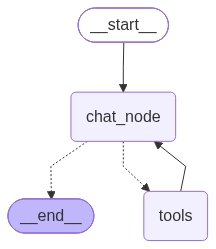

In [24]:
chatbot

In [25]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain how to find the ideal value of K in KNN"
                )
            )
        ]
    }
)

In [26]:
print(result['messages'][-1].content)

**How to pick the “right” *K* for a k‑Nearest‑Neighbors (KNN) model**  
*(Based on the concepts and examples that appear in the *Introduction to Machine Learning with Python* PDF notes)*  

---

## 1. Why *K* matters  

| K | Effect on the model |
|---|----------------------|
| **K = 1** | Very low bias, but high variance – the decision boundary follows every noise point. |
| **Large K** (e.g., K ≈ N) | Very high bias, low variance – the model becomes almost a constant‑prediction (the majority class). |
| **Intermediate K** | A trade‑off that usually gives the best **generalisation** (i.e., highest test accuracy). |

The goal is to find the *K* that minimises the **expected error on new data**. Because we cannot evaluate on truly unseen data while we are still tuning, we use **cross‑validation** (or a held‑out validation set) to estimate that error.

---

## 2. The systematic procedure (the one the notes recommend)

### Step 1 – Split the data (or set up a CV iterator)

```python
from 